In [1]:
import numpy as np
import dask , dask.distributed
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cmocean.cm as cmo
import warnings
warnings.simplefilter('ignore')
import dask_jobqueue
from astropy.convolution import Box2DKernel, convolve
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator, LongitudeLocator)
import matplotlib.colors as colors
import pandas as pd
import matplotlib.patches as mpatches
from fix_grid import fix_grid

In [2]:
pathf='/gxfs_work/geomar/smomw577/mesoscale_eddies/BOX_filtered/0181-0190/'
pathp='/gxfs_home/geomar/smomw577/plots/Boxcar/0181-0190/'

ds_original=xr.open_dataset('/gxfs_work/geomar/smomw577/mesoscale_eddies/MOM5_concat/0181-0190/MOM5_monthly_0181-0190_noice_all.nc')
dsa=xr.open_dataset(pathf+'3x3box_median_anomaly_monthly_0181-0190_all.nc')
ds_smoothed=xr.open_dataset(pathf+'3x3box_median_monthly_0181-0190_noice_all.nc')
ds_corr=xr.open_dataset(pathf+'3x3box_median_corr_monthly_0181-0190_noice_all.nc')
#mld_corr=xr.load_dataset(pathf+'3x3box_median_corr_monthly_mld_0181-0190_noice_all.nc', chunks='auto')
jpcorr_all=xr.open_dataset(pathf+'3x3box_median_corr_monthly_jp_0181-0190_noice_all.nc', chunks='auto')


ds_original=fix_grid(ds_original)
dsa=fix_grid(dsa)
ds_smoothed=fix_grid(ds_smoothed)
ds_corr=fix_grid(ds_corr)
#mld_corr=fix_grid(mld_corr)
jpcorr_all=fix_grid(jpcorr_all)

In [3]:
### select areas: start with solubility agulhas

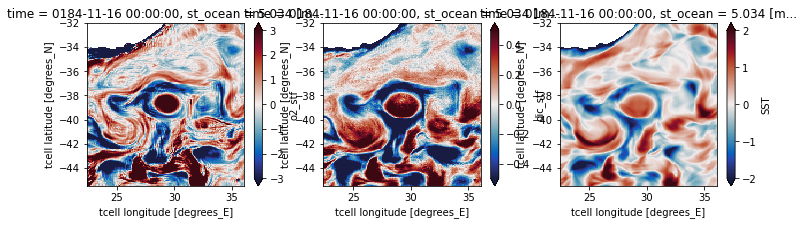

In [3]:
agulhas_s=dsa.sel(xt_ocean=slice(27.4,31.10), yt_ocean=slice(-40.5,-37))#.isel(time=46)
agulhas=dsa.isel(time=46).sel(xt_ocean=slice(22.4,36.10), yt_ocean=slice(-45.5,-32))
agulhas_all=dsa.sel(xt_ocean=slice(22.4,36.10), yt_ocean=slice(-45.5,-32))

fig,axs=plt.subplots(nrows=1, ncols=3, figsize=(12,3))
agulhas.o2_stf.plot(ax=axs[0],vmin=-3, vmax=3,cmap=cmo.balance)
agulhas.dic_stf.plot(ax=axs[1],vmin=-.5, vmax=.5,cmap=cmo.balance)
agulhas.SST.plot(ax=axs[2],vmin=-2, vmax=2,cmap=cmo.balance)

In [5]:
### next: biology brazil malvinas?

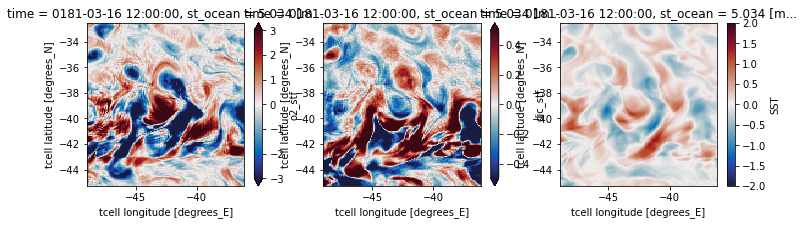

In [4]:
brazil_s=dsa.sel(xt_ocean=slice(-44.05,-41.15), yt_ocean=slice(-40.25,-37.5))#.isel(time=2)
brazil_all=dsa.sel(xt_ocean=slice(-49.05,-36.15), yt_ocean=slice(-45.25,-32.5))#.isel(time=2)
brazil=dsa.sel(xt_ocean=slice(-49.05,-36.15), yt_ocean=slice(-45.25,-32.5)).isel(time=2)
fig,axs=plt.subplots(nrows=1, ncols=3, figsize=(12,3))
brazil.o2_stf.plot(ax=axs[0],vmin=-3, vmax=3,cmap=cmo.balance)
brazil.dic_stf.plot(ax=axs[1],vmin=-.5, vmax=.5,cmap=cmo.balance)
brazil.SST.plot(ax=axs[2],vmin=-2, vmax=2,cmap=cmo.balance)
#brazil.jp_all.plot(ax=axs[2],vmin=-.2e-7, vmax=.2e-7,cmap=cmo.balance)

In [7]:
### respiration

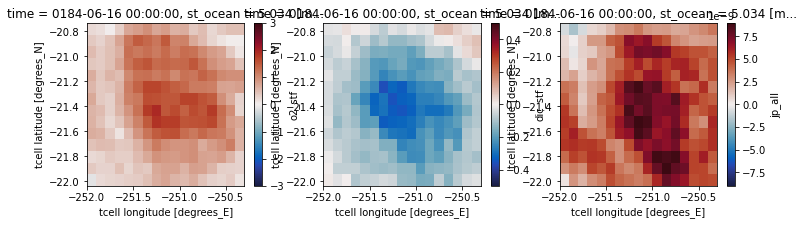

In [5]:
#xt_ocean=slice(-250,-247), yt_ocean=slice(-22,-20)
australia_s=dsa.sel(xt_ocean=slice(-252,-250.3), yt_ocean=slice(-22,-20.75)).isel(time=41)
#australia_s=dsa.sel(xt_ocean=slice(-254,-251), yt_ocean=slice(-23,-20))#.isel(time=42)
australia=dsa.sel(xt_ocean=slice(-255,-248), yt_ocean=slice(-25,-17.5)).isel(time=41)
australia_all=dsa.sel(xt_ocean=slice(-255,-248), yt_ocean=slice(-25,-17.5))

fig,axs=plt.subplots(nrows=1, ncols=3, figsize=(12,3))
australia_s.o2_stf.plot(ax=axs[0],vmin=-3, vmax=3,cmap=cmo.balance)
australia_s.dic_stf.plot(ax=axs[1],vmin=-.5, vmax=.5,cmap=cmo.balance)
australia_s.jp_all.plot(ax=axs[2],cmap=cmo.balance)
#australia.jp_all.plot(ax=axs[2],vmin=-.2e-7, vmax=.2e-7,cmap=cmo.balance)

In [6]:
def add_linreg(ax, x, y, color='k', lw=2):
    """
    Add linear regression line to an axis.

    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot the regression on
    x, y : array-like or xarray DataArray
        Data for regression
    color : str
        Line color
    lw : float
        Line width
    """
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return

    m, b = np.polyfit(x[mask], y[mask], 1)

    x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
    y_line = m * x_line + b

    ax.plot(x_line, y_line, color=color, linewidth=lw)

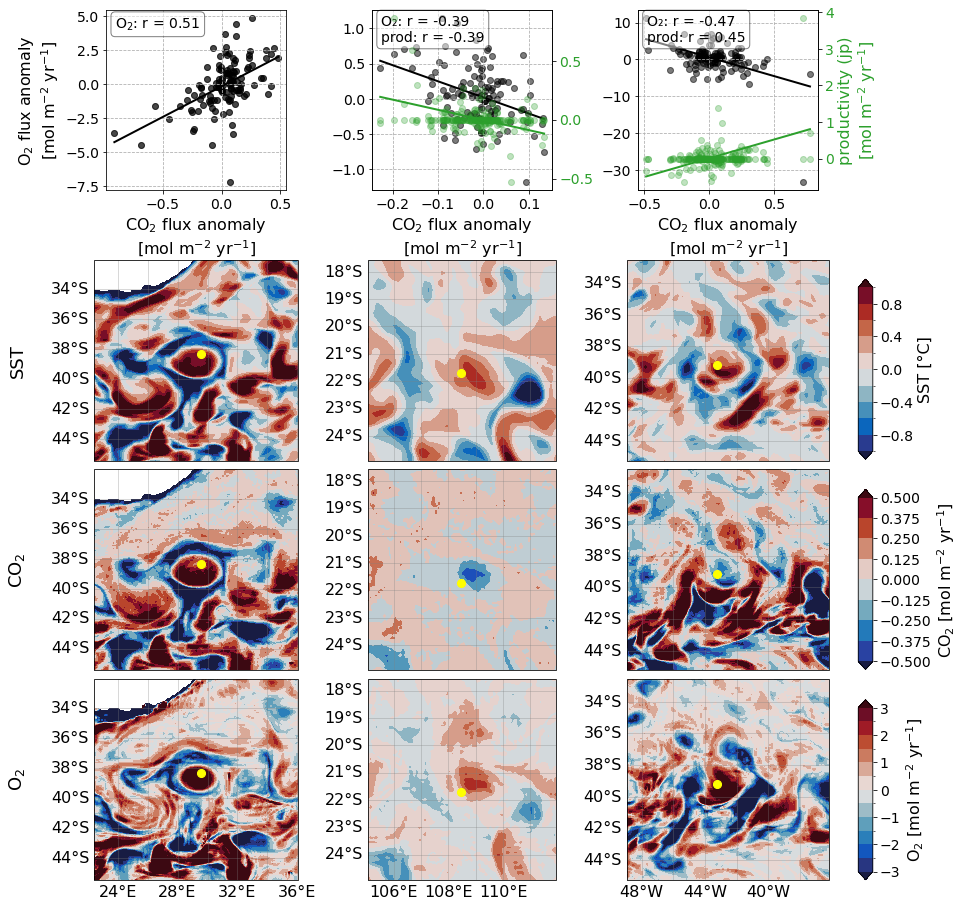

In [36]:
#small box
#agulhas_s=dsa.sel(xt_ocean=slice(27.4,31.10), yt_ocean=slice(-40.5,-37))#.isel(time=46)
#brazil_s=dsa.sel(xt_ocean=slice(-44.05,-41.15), yt_ocean=slice(-40.25,-37.5))#.isel(time=2)
#australia_s=dsa.sel(xt_ocean=slice(-254,-251), yt_ocean=slice(-23,-20))#.isel(time=42)

#single point
agulhas_sp=dsa.sel(xt_ocean=29.5, yt_ocean=-38.3, method='nearest')#.isel(time=46)
brazil_sp=dsa.sel(xt_ocean=-43.3, yt_ocean=-39.2, method='nearest')#.isel(time=2)
australia_sp=dsa.sel(xt_ocean=-251.55, yt_ocean=-21.71, method='nearest')#.isel(time=42)


fig,axs=plt.subplots(nrows=5, ncols=3, figsize=(13.5,16), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={
        'height_ratios': [1, 0.16, 1, 1, 1]  # second row = spacer
    })
for ax in axs[1, :]:
    ax.remove()
    
plt.rcParams.update({
    "font.size":16,
    "axes.titlesize":20,
    "axes.labelsize":16,
    "xtick.labelsize":14,
    "ytick.labelsize":14
})

#axs=axs.flatten()
m0=agulhas.o2_stf.plot.contourf(ax=axs[4,0], levels=13, vmin=-3, vmax=3,cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
m1=agulhas.dic_stf.plot.contourf(ax=axs[3,0],vmin=-.5, vmax=.5,levels=9, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
m2=agulhas.SST.plot.contourf(ax=axs[2,0],vmin=-1, vmax=1,levels=11, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)

brazil.o2_stf.plot.contourf(ax=axs[4,2], levels=13, vmin=-3, vmax=3,cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
brazil.dic_stf.plot.contourf(ax=axs[3,2],vmin=-.5, vmax=.5,levels=9, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
brazil.SST.plot.contourf(ax=axs[2,2],vmin=-1, vmax=1,levels=11, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
#
australia.o2_stf.plot.contourf(ax=axs[4,1], levels=13, vmin=-3, vmax=3,cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
australia.dic_stf.plot.contourf(ax=axs[3,1],vmin=-.5, vmax=.5,levels=9, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)
australia.SST.plot.contourf(ax=axs[2,1],vmin=-1, vmax=1,levels=11, cmap=cmo.balance, transform = ccrs.PlateCarree(), add_colorbar=False)

pos_sst = axs[2,2].get_position()
pos_dic = axs[3,2].get_position()
pos_o2  = axs[4,2].get_position()

# create aligned colorbar axes
cax0 = fig.add_axes([0.92, pos_sst.y0, 0.015, pos_sst.height])
cax1 = fig.add_axes([0.92, pos_dic.y0, 0.015, pos_dic.height])
cax2 = fig.add_axes([0.92, pos_o2.y0, 0.015, pos_o2.height])

cbar1=fig.colorbar(m2, cax=cax0)
cbar2=fig.colorbar(m1, cax=cax1)
cbar3=fig.colorbar(m0, cax=cax2)

cbar1.set_label('SST [°C]')
cbar2.set_label('CO$_2$ [mol m$^{-2}$ yr$^{-1}$]')
cbar3.set_label('O$_2$ [mol m$^{-2}$ yr$^{-1}$]')

for i in range(2,5):
    for j in range(3):
        gl = axs[i,j].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=.5, color='gray', alpha=0.6)
        gl.xlabels_top = False
        gl.ylabels_left = True
        gl.ylabels_right = False
        gl.xlabels_bottom = False
        if (i==4):
            gl.xlabels_bottom = True
### add rectangles

#rect_params = [
#    (27.4, -40.5,3.7, 3.5),   # rect1: lon_min, lat_min, width, height
#    (-44.05, -40.25, 2.9, 2.75),   # rect2
#    (-254, -23, 3, 3)    # rect3
#]
#
#for i in range(3):
#    lon, lat, w, h = rect_params[0]  # for axs[i,0]
#    rect = mpatches.Rectangle((lon, lat), w, h,
#                              linewidth=3, edgecolor='magenta', facecolor='none',
#                              transform=ccrs.PlateCarree())
#    axs[i,0].add_patch(rect)
#
#    lon, lat, w, h = rect_params[1]  # for axs[i,1]
#    rect = mpatches.Rectangle((lon, lat), w, h,
#                              linewidth=3, edgecolor='magenta', facecolor='none',
#                              transform=ccrs.PlateCarree())
#    axs[i,1].add_patch(rect)
#
#    lon, lat, w, h = rect_params[2]  # for axs[i,2]
#    rect = mpatches.Rectangle((lon, lat), w, h,
#                              linewidth=3, edgecolor='magenta', facecolor='none',
#                              transform=ccrs.PlateCarree())
#    axs[i,2].add_patch(rect)
    

for i in range(3):
    pos = axs[0, i].get_position() # Position speichern
    axs[0, i].remove()             # Karten-Achse löschen
    axs[0, i] = fig.add_axes(pos)  # Normale Achse an gleicher Stelle einfügen


axs[0,0].scatter(agulhas_sp.dic_stf, agulhas_sp.o2_stf, color='k', alpha=0.3, label='O2')

axs[0,2].scatter(brazil_sp.dic_stf, brazil_sp.o2_stf, color='k', alpha=0.3, label='O2')
axs[0,0].tick_params(axis='y', labelcolor='k')
axs[0,2].tick_params(axis='y', labelcolor='k')


# Zweite Achse erstellen, die die X-Achse teilt
ax2 = axs[0,2].twinx()  

# Zweiter Datensatz (Rechte Y-Achse)
ax2.scatter(brazil_sp.dic_stf, brazil_sp.jp_all, color='tab:green', alpha=0.3, label='JP')
ax2.tick_params(axis='y', labelcolor='tab:green')

axs[0,1].scatter(australia_sp.dic_stf, australia_sp.o2_stf, color='k', alpha=0.3, label='O2')
axs[0,1].tick_params(axis='y', labelcolor='k')
ax3 = axs[0,1].twinx()  
ax3.scatter(australia_sp.dic_stf, australia_sp.jp_all, color='tab:green', alpha=0.3, label='JP')
ax3.tick_params(axis='y', labelcolor='tab:green')

for i in range (3):
    axs[0,i].grid(linestyle='dashed')
    axs[0,i].set_xlabel('CO$_2$ flux anomaly\n[mol m$^{-2}$ yr$^{-1}$]')
    for j in [2,3,4]:
            axs[j,i].set_title('')
            if i ==0:
                axs[j,i].scatter(agulhas_sp.xt_ocean,agulhas_sp.yt_ocean, color='yellow', s=65)
            elif i==1:
                axs[j,i].scatter(australia_sp.xt_ocean,australia_sp.yt_ocean, color='yellow', s=65)
            elif i ==2:
                axs[j,i].scatter(brazil_sp.xt_ocean,brazil_sp.yt_ocean, color='yellow', s=65)

axs[0,0].set_ylabel('O$_2$ flux anomaly\n[mol m$^{-2}$ yr$^{-1}$]', color='k')
ax2.set_ylabel('productivity (jp)\n[mol m$^{-2}$ yr$^{-1}$]', color='tab:green')

#axs[0,0].set_title('Solubility', y=1.02)
#axs[0,1].set_title('Productivity', y=1.02)
#axs[0,2].set_title('Respiration', y=1.02)


agulhas_corr=xr.corr(agulhas_sp.dic_stf, agulhas_sp.o2_stf)
brazil_corr=xr.corr(brazil_sp.dic_stf, brazil_sp.o2_stf)
australia_corr=xr.corr(australia_sp.dic_stf, australia_sp.o2_stf)
brazil_corr_jp=xr.corr(brazil_sp.dic_stf, brazil_sp.jp_all)
australia_corr_jp=xr.corr(australia_sp.dic_stf, australia_sp.jp_all)

axs[0,0].text(
    0.05, 0.9,
    f"O$_2$: r = {agulhas_corr.item():.2f}",
    transform=axs[0,0].transAxes,
    fontsize=14,
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.5))


axs[0,2].text(
    0.05, 0.825,
    f"O₂: r = {brazil_corr.item():.2f}\nprod: r = {brazil_corr_jp.item():.2f}",
    transform=axs[0,2].transAxes,
    fontsize=14,
    color='black',  # text color
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.5)
)

axs[0,1].text(
    0.05, 0.825,
    f"O₂: r = {australia_corr.item():.2f}\nprod: r = {australia_corr_jp.item():.2f}",
    transform=axs[0,1].transAxes,
    fontsize=14,
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.5)
);

axs[0,0].scatter(agulhas_sp.dic_stf, agulhas_sp.o2_stf, color='black', alpha=0.6)
add_linreg(axs[0,0], agulhas_sp.dic_stf, agulhas_sp.o2_stf, color='black');

axs[0,2].scatter(brazil_sp.dic_stf, brazil_sp.o2_stf, color='black', alpha=0.3)
add_linreg(axs[0,2], brazil_sp.dic_stf, brazil_sp.o2_stf, color='black')

axs[0,1].scatter(australia_sp.dic_stf, australia_sp.o2_stf, color='black', alpha=0.3)
add_linreg(axs[0,1], australia_sp.dic_stf, australia_sp.o2_stf, color='black')

ax2.scatter(brazil_sp.dic_stf, brazil_sp.jp_all*60*60*24*365, color='tab:green', alpha=0.3)
add_linreg(ax2, brazil_sp.dic_stf, brazil_sp.jp_all*60*60*24*365, color='tab:green')

ax3.scatter(australia_sp.dic_stf, australia_sp.jp_all*60*60*24*365, color='tab:green', alpha=0.3)
add_linreg(ax3, australia_sp.dic_stf, australia_sp.jp_all*60*60*24*365, color='tab:green')


#ax2.set_ylim(-0.25e-7,0.4e-7)
#axs[3,1].set_ylim(-15,15)
axs[2,0].text(-0.33, 0.5, 'SST', va='center', ha='right', 
             transform=axs[2,0].transAxes, rotation=90, fontsize=18)

axs[3,0].text(-0.33, 0.5, 'CO$_2$', va='center', ha='right', 
             transform=axs[3,0].transAxes, rotation=90, fontsize=18)

axs[4,0].text(-0.33, 0.5, 'O$_2$', va='center', ha='right', 
             transform=axs[4,0].transAxes, rotation=90, fontsize=18)
fig.subplots_adjust(hspace=0.05)
plt.savefig(pathp+'Schematic_examples.png', dpi=300, bbox_inches='tight');